<a href="https://colab.research.google.com/github/KanSakamoto/ConcurrentProgrammingWithGo/blob/main/2026_Python%E3%83%81%E3%83%A5%E3%83%BC%E3%83%88%E3%83%AA%E3%82%A2%E3%83%AB%E8%AC%9B%E5%BA%A7%E4%B8%AD%E7%B4%9A%E7%B7%A8day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day1: ライブラリを使う

中級 Python チュートリアル — Day1

**今日のゴール**
- 基本文法を短く復習する
- リスト内包表記などでコードをスッキリ書く
- NumPy で配列・行列演算を扱う
- Matplotlib で可視化する
- 公開 API + JSONからデータを取得して可視化する

**必要なライブラリ**
```bash
numpy matplotlib requests
```


## 基本文法の確認

In [ ]:
# 簡単な数値計算（緑の部分はコメントです．プログラムとしては解釈されないため，説明を書く時などに使っています）

5 - 3 * 2 + 4

In [ ]:
# 変数に値を代入して使う

height = 1.73 # 身長が 1.73 m
weight = 68 # 体重が 68 kg

BMI = weight / (height * height)  # BMI = weight / height ** 2 のように書くことも可能

BMI

In [ ]:
# 文字列

string = 'こんにちは！'
print(string[2])
print(string[2:4])

In [ ]:
# リスト

## リストに対して使える便利な関数
l = [10, 20, 30]

s = sum(l) # 和
print(s)

length = len(l) # リストの要素数(長さ)
print(length)

## 多重リスト
multi_list = [[1,2,3],['abc','de'],[10,'ghij',[0,1,'hello']]]
print(multi_list)

In [ ]:
# if-elif-else文による条件分岐 (ジェットコースターの身長制限の判定をするプログラム)

height = 110
border_min = 120
border_max = 250

if height <= border_min:
    print('身長が120cm未満の方はジェットコースターには乗れません')
elif height > border_max:
    print('身長が250cm以上の方はジェットコースターには乗れません')
else:
    print('ジェットコースターに乗れます')

In [ ]:
# for文による繰り返し処理

for element in [10, 'ABC', 120]:
  print(element)

In [ ]:
# 関数

def get_sum(x, y):
  print('get_sum関数を実行しました． x+yを計算します')
  return x + y

print(get_sum(3, 5))

## コードをスッキリさせるテクニック




### リスト内包表記

問：0~4の平方を要素とするリストを作ってください。([0, 1, 4, 9, 16])

In [ ]:
# 素朴な解法

squares = []
for i in range(5):
  squares.append(i**2)

squares

リスト内包表記の記法：

`[式 for 要素 in イテラブルオブジェクト(リスト等)]`

In [ ]:
# リスト内包表記を用いる解法

squares = [i**2 for i in range(5)]

squares

### その他のスッキリ技


In [ ]:
# アンパック
a, b, c = [10, 20, 30]
print(a, b, c)

In [ ]:
# zip でまとめて回す
names = ["A", "B", "C"]
vals = [1, 2, 3]
paired = {k: v for k, v in zip(names, vals)}
print(paired)

In [ ]:
# f-string
temp = 22.5
print(f"気温は {temp:.1f} ℃ です")

In [ ]:
# 三項演算子
score = 50
label = "合格" if score >= 60 else "不合格"
print(label)

### 練習問題 1

1. `temps_c = [15.2, 18.0, 21.5, 19.3, 16.8]` から、華氏（`F = C * 9/5 + 32`）のリストを内包表記で作ってください。
2. そのうち **70°F 以上** の値だけ残してください。


In [ ]:
temps_c = [15.2, 18.0, 21.5, 19.3, 16.8]

# ここに書いてください
temps_f = None  # TODO
warm_f = None   # TODO

print(temps_f)
print(warm_f)


In [ ]:
# 解答例（まずは自分で書いてから見てください）
temps_f = [c * 9 / 5 + 32 for c in temps_c]
warm_f = [f for f in temps_f if f >= 70]
print(temps_f)
print(warm_f)


## NumPy
### 数値計算のためのライブラリ
* 高速な行列計算ができる
* 簡単に数列を生成できる

In [ ]:
# numpyを"np"としてインポート
import numpy as np

### 配列の作成と基本操作


In [ ]:
# リストから配列へ
a = np.array([1, 2, 3, 4, 5], dtype=float)
print(a)
print("shape:", a.shape, "dtype:", a.dtype)

In [ ]:
# 指定した形の、0埋め配列を作る
# np.zeros(形状)  … 例: 5 や (2, 3)
zeros = np.zeros(5)
print("zeros:", zeros)

In [ ]:
# 等間隔な数列を生成
# np.linspace(開始, 終了, 数列数)
a = np.linspace(0, 10, 51) # 0~10の区間を等間隔に51等分した数列を生成
print(a)

In [ ]:
# 0以上1未満の乱数を生成
a = np.random.rand(5) # 0以上1未満の5個の乱数から成る数列を生成
print(a)

In [ ]:
# 整数の乱数を生成
a = np.random.randint(0, 100, (4, 3)) # 0以上100未満の 4 x 3 の整数乱数を生成
print(a.shape)
print(a)

### ベクトル演算（リストとの違い）


In [ ]:
xs = np.array([1.0, 2.0, 3.0, 4.0])

# 要素ごとの演算が一気にできる
print(xs * 2)
print(xs ** 2)
print(np.sqrt(xs))
print(xs + np.array([10, 20, 30, 40]))

# 統計
print("mean:", xs.mean(), "sum:", xs.sum(), "max:", xs.max())


### 2次元配列（行列）


In [ ]:
A = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
])
B = np.array([
    [5.0, 6.0],
    [7.0, 8.0],
])

print("A:\n", A)
print("形:", A.shape)          # (行, 列)
print("転置:\n", A.T)
print("要素ごと積:\n", A * B)  # Hadamard積


### 参考：行列積

機械学習やデータ分析では行列積（線形変換）が頻出です。

- 要素ごとの積: `A * B`
- 行列積: `A @ B` または `np.dot(A, B)`


In [ ]:
# 行列積
C = A @ B
print("A @ B =\n", C)

# ベクトルへの線形変換
v = np.array([1.0, 1.0])
print("A @ v =", A @ v)

# 形が合わないとエラーになる（確認してみてもよい）
# np.array([[1, 2, 3]]) @ A


<img src="https://atarimae.biz/wp-content/uploads/2018/06/2-2matrix-pr1806.png">

画像元: https://atarimae.biz/archives/23930

### 練習問題 2

次の行列 `M` とベクトル `w` について、`M @ w` を計算してください。


In [ ]:
M = np.array([
    [2.0, 0.0],
    [0.0, 3.0],
    [1.0, 1.0],
])
w = np.array([4.0, 5.0])

# ここに書いてください
result = None  # TODO
print(result)


In [ ]:
# 解答例
result = M @ w
print(result)  # [8. 15. 9.]


## Matplotlib
### グラフ描画のためのライブラリ
* 簡単にデータからグラフを描画できる


In [ ]:
# Matplotlibのpyplotモジュールを"plt"としてインポート
import matplotlib.pyplot as plt

### 折れ線グラフ


In [ ]:
# y=x^2 のグラフを描画
x = np.linspace(0, 1, 100) # 0~1の区間を等間隔に100等分した数列を生成
y = x ** 2
plt.plot(x, y, label='label') # xとyをプロット
plt.legend()
plt.show() # グラフを出力

### 棒グラフ・散布図


In [ ]:
# 散布図

# 乱数を生成
x = np.random.rand(100)
y = np.random.rand(100)

# 描画
plt.scatter(x, y)
plt.show()

### 練習問題 3

`np.linspace(-2, 2, 100)` で作った `x` に対し、`y = x ** 2 + 2 * x` のグラフを描いてください。


In [ ]:
# ここに書いてください


In [ ]:
# 解答例
x = np.linspace(-2, 2, 100)
y = x ** 2 + 2 * x

plt.plot(x, y, label='label')
plt.legend()
plt.show()


## 公開 API + JSON でデータを取る

今日やること:
1. API を叩くときの約束事（レート制限・ステータスコード・マナー）を理解する
2. `requests` で HTTP GET
3. `.json()` で Python の辞書／リストに変換
4. 必要なキーを取り出す（ネストした構造を掘る）
5. NumPy / Matplotlib で可視化
6. （おまけ）CSV に保存する

使用 API: [Open-Meteo](https://open-meteo.com/)（学習用に使いやすい。ただし無制限ではない）


### APIとは何か

**API**（Application Programming Interface）は、  
プログラム同士が決まった形式でデータをやり取りするための仕組みです。

今日扱うのはそのうちの **Web API** です。

- こちら：URL とパラメータを指定してリクエストを送る
- 相手：決まった形式（多くは **JSON**）でデータを返す

ブラウザでニュースサイトを見る代わりに、  
プログラムが「データだけください」と取りにいくイメージです。

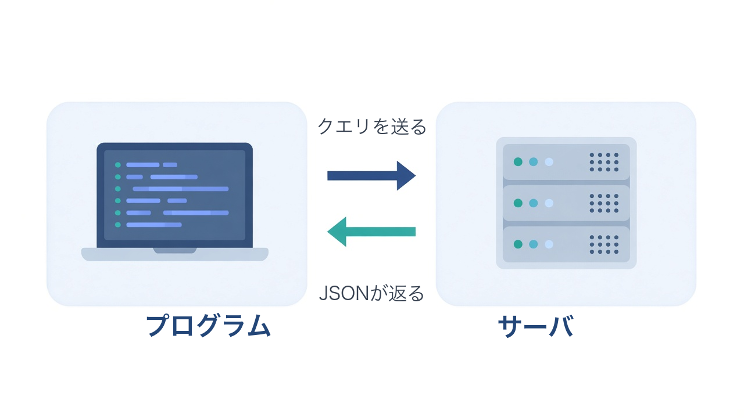

### 約束事：レート制限と API マナー

外部のサーバーにリクエストを送る行為は、相手のコンピュータ資源を使わせてもらっているということです。  
「動いたから何度でも回す」「クラス全員で同じエンドポイントを連打する」は、相手から見ると攻撃に近い負荷になりえます。


#### レート制限（rate limit）とは

一定時間あたりに送ってよいリクエスト数の上限です。

| 例（イメージ） | 意味 |
|----------------|------|
| 60 回 / 分 | 1分に60回まで |
| 10,000 回 / 日 | 1日の合計上限 |
| 同時接続数の制限 | 並列に開きすぎない |

制限を超えると、大体の場合次のどれかが起きます。

- HTTP **429 Too Many Requests**（リクエストが多すぎる）
- **403 Forbidden** / 一時的な IP ブロック
- APIキーの停止、有料プランへの強制、利用規約違反の警告
- 相手サービスやネットワーク管理者からの問い合わせ

#### 授業・チュートリアルで特に危ないパターン

次はやってはいけない例です。

- `for` / `while` の中で API を連打する
- セルを何度も連続実行して、同じ取得を何十回も繰り返す

1回取って CSV に残す → あとはファイルを読む

を基本にしてください。


#### ステータスコードを読む（最低限）

| コード | 意味 | 取るべき行動 |
|--------|------|----------------|
| 200 | 成功 | そのまま使う |
| 401 | 認証が必要 / キーが違う | キーと権限を確認。連打しない |
| 403 | 拒否（権限・利用条件・ブロック等） | ドキュメントと利用状況を確認。連打しない |
| 404 | URL やリソースが無い | エンドポイントを見直す |
| **429** | **レート制限** | **すぐに再送しない。待ってから少数回だけ試す** |
| 5xx | サーバー側の不調 | こちらが原因とは限らない。間隔を空けて少数回 |

`raise_for_status()` は便利ですが、「失敗した理由」を自分で読めるようにしておくと安全です。


#### 実務で守るチェックリスト

API を使う前に、ドキュメントで次を確認します。

1. **利用規約 / Terms**（商用利用可否、再配布、帰属表示）
2. **レート制限の数値**（無料枠と有料枠の違い）
3. **APIキーが必要か**（必要なら発行方法と保管方法）
4. **キャッシュや一括取得**の推奨（1件ずつより、まとめて取る API がある）
5. **連絡先・ダッシュボード**（制限超過の見え方）

キーがある場合の鉄則:

- ノートブックや Git に生のキーを書かない（環境変数や、Git 管理外の設定ファイルへ）
- キーを Slack / メールで雑に共有しない
- 漏れたら再発行

Open-Meteo はキーなしで始めやすいですが、[利用条件・制限](https://open-meteo.com/en/terms)は必ず目を通すようにしましょう。  


次のセルで、「成功/失敗の見分け」と「丁寧なリクエスト」の型を確認します。


In [ ]:
import time

def fetch_json(url, params=None, timeout=30):

  """API を1回呼び、失敗時は理由が分かるようにする（連打しない）"""
  response = requests.get(url, params=params, timeout=timeout)

  print("status:", response.status_code)
  # サーバーが「何秒待て」と教えてくれることがある
  retry_after = response.headers.get("Retry-After")
  if retry_after:
    print("Retry-After:", retry_after, "秒待つのが望ましい")

  if response.status_code == 429:
    raise RuntimeError(
        "レート制限に達しました。すぐに再実行せず、"
        "しばらく待つか、保存済みファイルを使ってください。"
    )
  if response.status_code >= 400:
    # 本文にヒントが入っていることが多い
    raise RuntimeError(
        f"リクエスト失敗: {response.status_code}\n{response.text[:300]}"
    )

  return response.json()


# NG例:
# for _ in range(100):
#     fetch_json(url, params)

### API にリクエストを送る

ここでは1回だけ取得します。うまく取れたら、あとで CSV に残して再利用します。


In [ ]:
# ライブラリをインポート
import requests

In [ ]:
# 東京付近の緯度・経度
latitude = 35.68
longitude = 139.65

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "daily": ["temperature_2m_max,temperature_2m_min,precipitation_sum"],
    "timezone": "Asia/Tokyo",
    "forecast_days": 7,
}

In [ ]:
# 重要: このセルは何度も連打しない。失敗しても即座に再実行しない。
data = fetch_json(url, params=params)
print(type(data))

In [ ]:
# 実際に叩いた URL を確認したいとき
# （デバッグ用。共有・提出物に APIキー付き URL を貼らないこと）
demo = requests.Request("GET", url, params=params).prepare()
print("request URL:", demo.url)

### JSON の中身を確認する

JSON は「ネストした辞書・リスト」です。まず全体構造を把握してから、必要なキーを取り出します。


In [ ]:
pprint(data)


In [ ]:
# キーの一覧
print(data.keys())
print(data["daily"].keys())


### 必要なデータを取り出す


In [ ]:
daily = data["daily"]

dates = daily["time"]
tmax = daily["temperature_2m_max"]
tmin = daily["temperature_2m_min"]
rain = daily["precipitation_sum"]

# リスト内包で日較差（最高 - 最低）も作る
trange = [hi - lo for hi, lo in zip(tmax, tmin)]

for d, hi, lo, r in zip(dates, tmax, tmin, rain):
    print(f"{d}: 最高 {hi:.1f}℃ / 最低 {lo:.1f}℃ / 降水 {r:.1f}mm")


### NumPy で集計し、Matplotlib で可視化


In [ ]:
tmax_arr = np.array(tmax, dtype=float)
tmin_arr = np.array(tmin, dtype=float)
rain_arr = np.array(rain, dtype=float)

print(f"最高気温の平均: {tmax_arr.mean():.2f} ℃")
print(f"最低気温の平均: {tmin_arr.mean():.2f} ℃")
print(f"降水量の合計: {rain_arr.sum():.2f} mm")


In [ ]:
x = np.arange(len(dates))

plt.figure(figsize=(8, 4))
plt.plot(x, tmax_arr, marker="o", label="max")
plt.plot(x, tmin_arr, marker="o", label="min")
plt.xticks(x, dates, rotation=45, ha="right")
plt.ylabel("temperature (℃)")
plt.title("Tokyo: 7-day temperature forecast")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(x, rain_arr, color="steelblue")
plt.xticks(x, dates, rotation=45, ha="right")
plt.ylabel("precipitation (mm)")
plt.title("Tokyo: daily precipitation")
plt.tight_layout()
plt.show()


### おまけ: CSV に保存（再取得を減らす）

一度保存すれば API を何度も叩かなくてよい、というレート制限対策にもなります。


In [ ]:
import csv
from pathlib import Path

out_path = Path("tokyo_weather_7days.csv")

with out_path.open("w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["date", "temp_max", "temp_min", "precipitation", "temp_range"])
    for row in zip(dates, tmax, tmin, rain, trange):
        writer.writerow(row)

print("保存しました:", out_path.resolve())


### 練習問題 4.1

`latitude` / `longitude` を別の都市（例: 大阪 `34.69, 135.50`）に変えて1回だけ取得し、同じグラフを描いてください。


In [ ]:
# ここに書いてください

In [ ]:
# 大阪付近の緯度・経度
latitude = 34.69
longitude = 135.50

# パラメータの設定
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "daily": ["temperature_2m_max,temperature_2m_min,precipitation_sum"],
    "timezone": "Asia/Tokyo",
    "forecast_days": 7,
}

# APIは一回だけ叩く
data = fetch_json(url, params=params)

# JSONからデータを切り出す
daily = data["daily"]

dates = daily["time"]
tmax = daily["temperature_2m_max"]
tmin = daily["temperature_2m_min"]
rain = daily["precipitation_sum"]

# Numpyに変換
tmax_arr = np.array(tmax, dtype=float)
tmin_arr = np.array(tmin, dtype=float)
rain_arr = np.array(rain, dtype=float)

x = np.arange(len(dates))

# Matplotlibで出力
plt.figure(figsize=(8, 4))
plt.plot(x, tmax_arr, marker="o", label="max")
plt.plot(x, tmin_arr, marker="o", label="min")
plt.xticks(x, dates, rotation=45, ha="right")
plt.ylabel("temperature (℃)")
plt.title("Osaka: 7-day temperature forecast")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 練習問題4.2
 リスト内包表記で「降水量が 1mm 以上の日付」だけ抜き出してください。


In [ ]:
# 4.2のひな形
rainy_dates = None  # TODO: dates と rain から作る
print(rainy_dates)


In [ ]:
# 4.2の解答例
rainy_dates = [d for d, r in zip(dates, rain) if r >= 1.0]
print(rainy_dates)


### 練習問題 4.3
（発展）`hourly=temperature_2m` を付けて取得する。取れたら可視化し、できればファイル保存してください。  
   うまくいかないときは連打せず、ドキュメントとステータスコードを確認してください。

In [ ]:
# ここに書いてください

In [ ]:
# 大阪付近の緯度・経度
latitude = 34.69
longitude = 135.50

# パラメータの設定
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": latitude,
    "longitude": longitude,
    "hourly": "temperature_2m", # 気温のキー
    "timezone": "Asia/Tokyo",
    "forecast_days": 2, # 日数を減らす
}
# APIは一回だけ叩く
data = fetch_json(url, params=params)

# JSONからデータを切り出す
hourly = data["hourly"]

hours = hourly["time"]
temp_h = hourly["temperature_2m"]

# 2日目のみを使用（1日目は今日であるため）
hours = hours[24:]
temp_h = temp_h[24:]

# Numpyに変換
temp_h_arr = np.array(temp_h, dtype=float)

x = np.arange(len(hours))

# Matplotlibで出力
plt.figure(figsize=(8, 4))
plt.plot(x, temp_h_arr, marker="o", label="max")
plt.xticks(x, hours, rotation=45, ha="right")
plt.ylabel("temperature (℃)")
plt.title("Osaka: 1-day temperature forecast")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 今日のまとめ

| トピック | できるようになったこと |
|----------|------------------------|
| 基本文法 | 変数・リスト・辞書・関数・ループ |
| リスト内包表記 | `for` + `append` を短く書く |
| NumPy | 配列演算・行列積 `@` |
| Matplotlib | 折れ線・棒・散布図 |
| API マナー | レート制限・429・保存して再利用・キーを漏らさない |
| API + JSON | `requests` → `.json()` → 可視化 / CSV保存 |


### （余談）ほかにもこんな API がある

Open-Meteo 以外でも、「公式 Docs を見て `url` と `params` を決める」流れは同じです。  
学習・試作向けに使いやすいものを挙げます（利用条件・レート制限は必ず公式で確認）。

- [Open-Meteo Air Quality API](https://open-meteo.com/en/docs/air-quality-api) … 大気質（PM2.5 など）。同じ公式内の別エンドポイント
- [JSONPlaceholder](https://jsonplaceholder.typicode.com/) … 偽の REST API。投稿・ユーザーなどを練習用に GET/POST できる
- [PokéAPI](https://pokeapi.co/docs/v2) … ポケモンデータ。キーなし、JSON、ドキュメントが読みやすい
- [REST Countries](https://restcountries.com/) … 国名から首都・人口・通貨などを取得
- [Open Library API](https://openlibrary.org/developers/api) … 書籍情報（タイトル・著者など）を検索・取得
- [Frankfurter](https://www.frankfurter.app/docs/) … 為替レート（ECB ベース）。キーなしで通貨換算の練習向き
- [GitHub REST API](https://docs.github.com/en/rest) … 公開リポジトリ情報など。実務に近いが、制限・認証の話が出やすい
- [zipcloud 郵便番号検索 API](https://zipcloud.ibsnet.co.jp/doc/api) … 郵便番号から住所。日本のデータで試しやすい

**使い方の型（共通）**
1. 公式 Docs を開く  
2. エンドポイントとパラメータを確認する  
3. まずブラウザや1回の `requests.get` で JSON を見る  
4. 必要なキーだけ取り出す（取りすぎ・連打しない）